In [2]:
import pandas as pd

sql_fact = pd.read_csv("sql fact file.csv")

print(sql_fact.shape)
print(sql_fact.columns.tolist())

(20000, 21)
['TripID', 'RouteKey', 'BusKey', 'TimeKey', 'PerfKey', 'StartTime', 'EndTime', 'FuelConsumed', 'Distance', 'TargetTime', 'ActualTime', 'DelayAnalysis', 'OperatingCostPerKM', 'PassengerCount', 'EngineTemperature', 'RPM', 'FuelRate', 'IdleDuration', 'AverageSpeed', 'BrakeEvents', 'OTPFlag']


In [3]:
sql_fact['FuelPerKM'] = sql_fact['FuelConsumed'] / sql_fact['Distance']

print(sql_fact[['FuelConsumed', 'Distance', 'FuelPerKM']].head())
print(sql_fact.shape)

   FuelConsumed  Distance  FuelPerKM
0          5.91     13.14   0.449772
1          2.38      5.31   0.448211
2         19.65     58.13   0.338035
3         17.25     72.43   0.238161
4          2.31     55.86   0.041353
(20000, 22)


In [4]:
Q1 = sql_fact['FuelPerKM'].quantile(0.25)
Q3 = sql_fact['FuelPerKM'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fuel_anomalies = sql_fact[
    (sql_fact['FuelPerKM'] < lower_bound) |
    (sql_fact['FuelPerKM'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("Fuel Siphoning Anomalies:", len(fuel_anomalies))

Q1: 0.13519850288855448
Q3: 0.4420362795955639
IQR: 0.3068377767070094
Lower Bound: -0.3250581621719596
Upper Bound: 0.902292944656078
Fuel Siphoning Anomalies: 1894


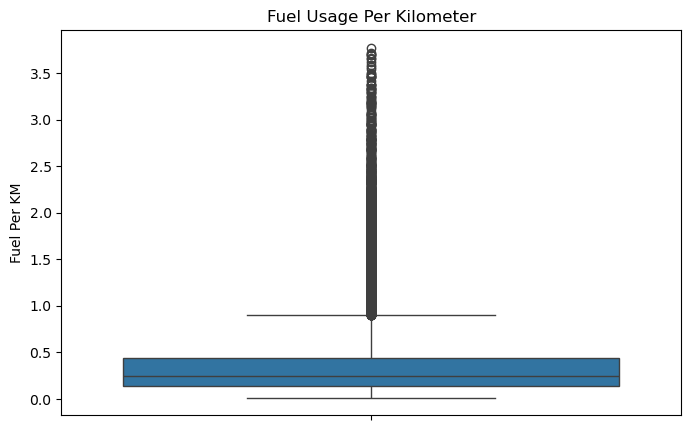

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(y=sql_fact['FuelPerKM'])

plt.title('Fuel Usage Per Kilometer')
plt.ylabel('Fuel Per KM')

plt.show()

In [6]:
high_fuel = sql_fact['FuelConsumed'].quantile(0.90)

low_idle = sql_fact['IdleDuration'].quantile(0.10)

print("High Fuel Threshold:", high_fuel)
print("Low Idle Threshold:", low_idle)

engine_faults = sql_fact[
    (sql_fact['FuelConsumed'] >= high_fuel) &
    (sql_fact['IdleDuration'] <= low_idle)
]

print("Engine Fault Candidates:", len(engine_faults))

High Fuel Threshold: 18.09
Low Idle Threshold: 5.0
Engine Fault Candidates: 212
